In [1]:
# Model 3 — Order Value Predictor
## Predicting the total value of an order (Regression)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import joblib
import json
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
print("All imports successful")

All imports successful


In [3]:
## Step 1 — Load Data from Warehouse

In [4]:
BASE_DIR = Path().resolve().parent
conn = duckdb.connect(str(BASE_DIR / "data/warehouse/olist.duckdb"))

df = conn.execute("""
    SELECT
        f.order_id,
        f.total_price,
        f.total_freight,
        f.item_count,
        f.customer_state,
        f.is_late,
        p.product_category_name_english AS category,
        p.product_weight_g,
        p.product_length_cm,
        p.product_height_cm,
        p.product_width_cm,
        pay.payment_type,
        pay.payment_installments,
        s.seller_state,
        EXTRACT('month' FROM f.order_purchase_timestamp) AS order_month,
        EXTRACT('dayofweek' FROM f.order_purchase_timestamp) AS order_dayofweek
    FROM fact_orders f
    LEFT JOIN dim_product p ON f.product_id = p.product_id
    LEFT JOIN dim_payment pay ON f.order_id = pay.order_id
    LEFT JOIN dim_seller s ON f.seller_id = s.seller_id
    WHERE f.total_price IS NOT NULL
    AND f.total_price > 0
    AND f.order_status = 'delivered'
""").df()

conn.close()

print(f"Dataset shape: {df.shape}")
print(f"\nTarget — total_price statistics:")
print(df["total_price"].describe())

Dataset shape: (100176, 16)

Target — total_price statistics:
count    100176.000000
mean        137.073339
std         209.519142
min           0.850000
25%          45.900000
50%          85.990000
75%         149.900000
max       13440.000000
Name: total_price, dtype: float64


In [5]:
## Step 2 — Feature Engineering

In [6]:
# Fill nulls
num_cols = [
    "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm",
    "payment_installments"
]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = ["category", "customer_state", "seller_state", "payment_type"]
for col in cat_cols:
    df[col] = df[col].fillna("unknown")

# Feature: product volume
df["product_volume_cm3"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

# Feature: freight ratio
df["freight_ratio"] = df["total_freight"] / (df["total_price"] + 1)

# Feature: is same state
df["is_same_state"] = (df["customer_state"] == df["seller_state"]).astype(int)

# Log transform target — reduces effect of extreme outliers
df["log_total_price"] = np.log1p(df["total_price"])

# Encode categoricals
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Feature engineering complete")
print(f"Dataset shape: {df.shape}")

Feature engineering complete
Dataset shape: (100176, 20)


In [7]:
## Step 3 — Train/Test Split

In [8]:
FEATURES = [
    "total_freight", "item_count",
    "product_weight_g", "product_volume_cm3",
    "freight_ratio", "is_same_state",
    "customer_state", "seller_state", "category",
    "payment_type", "payment_installments",
    "order_month", "order_dayofweek"
]

TARGET = "log_total_price"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (80140, 13)
Test set     : (20036, 13)


In [9]:
## Step 4 — Train Models

In [10]:
# Model 1 — Linear Regression baseline
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Model 2 — Ridge Regression
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

# Model 3 — Lasso Regression
pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, random_state=42, max_iter=1000))
])

# Model 4 — XGBoost Regressor
pipe_xgb = Pipeline([
    ("model", XGBRegressor(
        n_estimators=100,
        random_state=42,
        verbosity=0
    ))
])

print("Training Linear Regression...")
pipe_lr.fit(X_train, y_train)

print("Training Ridge...")
pipe_ridge.fit(X_train, y_train)

print("Training Lasso...")
pipe_lasso.fit(X_train, y_train)

print("Training XGBoost...")
pipe_xgb.fit(X_train, y_train)

print("\nAll models trained successfully")

Training Linear Regression...
Training Ridge...
Training Lasso...
Training XGBoost...

All models trained successfully


In [11]:
## Step 5 — Evaluate Models

In [12]:
models = {
    "Linear Regression": pipe_lr,
    "Ridge":             pipe_ridge,
    "Lasso":             pipe_lasso,
    "XGBoost":           pipe_xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Convert back from log scale to original scale
    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae  = mean_absolute_error(y_test_actual, y_pred_actual)
    r2   = r2_score(y_test_actual, y_pred_actual)

    results.append({
        "Model": name,
        "RMSE":  round(rmse, 2),
        "MAE":   round(mae, 2),
        "R²":    round(r2, 4)
    })

results_df = pd.DataFrame(results)
print("=" * 55)
print("MODEL COMPARISON — ORDER VALUE PREDICTOR")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)
print("\nMetric guide:")
print("RMSE — avg prediction error in BRL (lower is better)")
print("MAE  — avg absolute error in BRL (lower is better)")
print("R²   — how much variance explained (higher is better)")

MODEL COMPARISON — ORDER VALUE PREDICTOR
            Model   RMSE   MAE      R²
Linear Regression 396.52 63.57 -2.7022
            Ridge 396.50 63.57 -2.7018
            Lasso 355.76 62.33 -1.9802
          XGBoost  28.85  4.64  0.9804

Metric guide:
RMSE — avg prediction error in BRL (lower is better)
MAE  — avg absolute error in BRL (lower is better)
R²   — how much variance explained (higher is better)


In [13]:
## Step 6 — Visualize Predictions

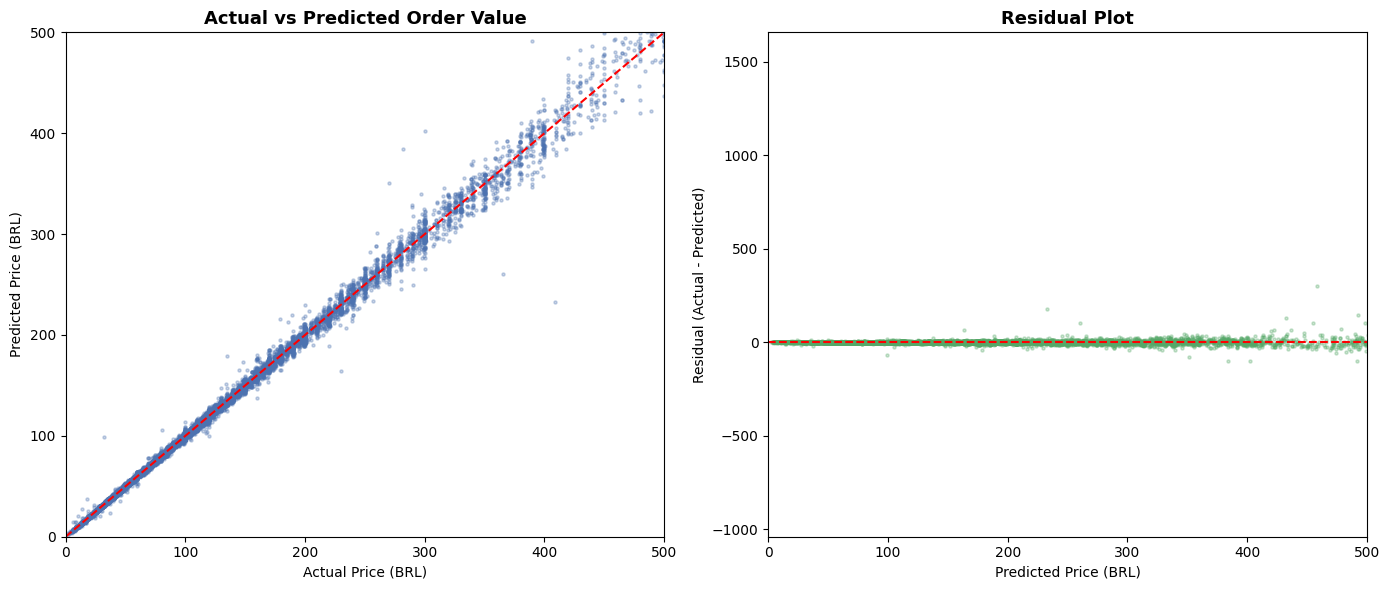

Chart saved


In [14]:
y_pred_xgb = np.expm1(pipe_xgb.predict(X_test))
y_test_actual = np.expm1(y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
ax1.scatter(y_test_actual, y_pred_xgb, alpha=0.3, color="#4C72B0", s=5)
ax1.plot([0, 500], [0, 500], "r--", linewidth=1.5)
ax1.set_xlim(0, 500)
ax1.set_ylim(0, 500)
ax1.set_title("Actual vs Predicted Order Value", fontsize=13, fontweight="bold")
ax1.set_xlabel("Actual Price (BRL)")
ax1.set_ylabel("Predicted Price (BRL)")

# Residuals
residuals = y_test_actual - y_pred_xgb
ax2.scatter(y_pred_xgb, residuals, alpha=0.3, color="#55A868", s=5)
ax2.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
ax2.set_xlim(0, 500)
ax2.set_title("Residual Plot", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicted Price (BRL)")
ax2.set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.savefig("../reports/figures/17_order_value_predictions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

In [15]:
## Step 7 — Save Best Model

In [16]:
MODELS_DIR = BASE_DIR / "src/ml/saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipe_xgb, MODELS_DIR / "order_value_predictor.pkl")

with open(MODELS_DIR / "order_value_predictor_features.json", "w") as f:
    json.dump(FEATURES, f)

# Verify
loaded_model = joblib.load(MODELS_DIR / "order_value_predictor.pkl")
test_pred = np.expm1(loaded_model.predict(X_test[:5]))
print("Sample predictions (BRL):")
for i, pred in enumerate(test_pred):
    print(f"  Order {i+1}: R${pred:.2f}")

print("\nModel saved and verified successfully")

Sample predictions (BRL):
  Order 1: R$158.12
  Order 2: R$762.39
  Order 3: R$132.79
  Order 4: R$112.60
  Order 5: R$191.35

Model saved and verified successfully
